# Edmonton Residential Waste Cart Rollout Analysis

### A portfolio case study using City of Edmonton Open Data and 2021 Census data

**Business question**

How did Edmonton's residential cart rollout vary across time and neighbourhoods, and how does the picture change after accounting for neighbourhood size, occupied dwellings, and recent population growth?

**Why this matters**

Raw cart counts can overstate the importance of large neighbourhoods. This analysis moves from absolute counts to more decision-useful measures, especially **carts with 2021 install dates per 1,000 occupied dwellings**.

**Tools demonstrated**

Python · pandas · REST/Socrata API · GeoPandas · Matplotlib · Census normalization · Data-quality auditing · Correlation · Segmentation · Outlier analysis

## Executive summary

This notebook is structured like an analyst deliverable rather than a coding exercise.

The analysis is designed to establish five things:

- when the main cart rollout activity occurred;
- which neighbourhoods were most affected;
- whether rollout timing was spatially structured;
- whether population or occupied dwellings provide a better denominator;
- whether rapid neighbourhood growth helps explain unusually high rollout intensity.

> **Important:** `Cart Counts` should be treated as a snapshot of active carts grouped by installation date, not as a complete historical transaction log of every cart installation and removal.

## 1. Setup and reusable API helper

The notebook queries Edmonton Open Data directly. Aggregation is performed on the server where possible, so the full Cart Counts dataset does not need to be downloaded.

In [1]:
import numpy as np
import pandas as pd
import requests
from io import StringIO

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

CART_URL = "https://data.edmonton.ca/resource/q2sn-xztr.csv"
POP_2019_URL = "https://data.edmonton.ca/resource/a6zx-dzqn.csv"
POP_2021_URL = "https://data.edmonton.ca/resource/eg3i-f4bj.csv"
CENSUS_2021_SHORT_URL = "https://data.edmonton.ca/resource/rw8s-vqrs.csv"

def api_query(url, params=None):
    response = requests.get(url, params=params or {}, timeout=60)
    response.raise_for_status()
    return pd.read_csv(StringIO(response.text))

MONTH_NAMES = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

## 2. Data-quality audit

Before interpreting patterns, verify the actual date range, record count, product categories, and annual distribution.

This is important because metadata descriptions and observed values do not always align perfectly.

In [2]:
date_range = api_query(
    CART_URL,
    {
        "$select": """
            min(install_date) as earliest_install,
            max(install_date) as latest_install,
            count(*) as rows
        """
    }
)

date_range

,earliest_install,latest_install,rows
0,2019-03-10T00:00:00.000,2024-09-10T00:00:00.000,37734


In [3]:
products = api_query(
    CART_URL,
    {
        "$select": """
            product_description,
            sum(number_of_carts) as carts,
            count(*) as records
        """,
        "$group": "product_description",
        "$order": "sum(number_of_carts) DESC"
    }
)

products["carts"] = pd.to_numeric(products["carts"], errors="coerce")
products["records"] = pd.to_numeric(products["records"], errors="coerce")

products

,product_description,carts,records
0,120 Liter Organic Cart,271572,12823
1,240 Liter Garbage Cart,242332,18442
2,120 Liter Garbage Cart,26823,5077
3,360 Liter Garbage Cart,2995,1174
4,360 Liter Organic Cart,1311,136
5,240 Liter Organic Cart,813,82


In [4]:
yearly = api_query(
    CART_URL,
    {
        "$select": """
            date_extract_y(install_date) as year,
            sum(number_of_carts) as carts_installed,
            count(*) as records
        """,
        "$group": "date_extract_y(install_date)",
        "$order": "date_extract_y(install_date)"
    }
)

for col in ["year", "carts_installed", "records"]:
    yearly[col] = pd.to_numeric(yearly[col], errors="coerce")

yearly["share_pct"] = yearly["carts_installed"] / yearly["carts_installed"].sum() * 100

yearly

,year,carts_installed,records,share_pct
0,2019,15760,1298,2.887261
1,2020,104266,4164,19.101725
2,2021,389532,24353,71.362985
3,2022,13194,2900,2.417165
4,2023,15904,3638,2.913642
5,2024,7190,1381,1.317221


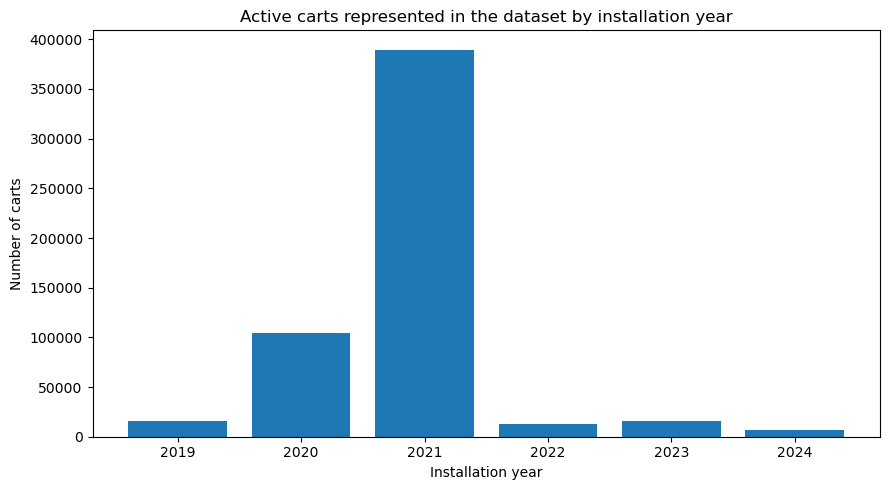

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(yearly["year"].astype("Int64").astype(str), yearly["carts_installed"])
ax.set_title("Active carts represented in the dataset by installation year")
ax.set_xlabel("Installation year")
ax.set_ylabel("Number of carts")
plt.tight_layout()
plt.show()

### Data-quality takeaway

If the observed install-date range extends outside the period emphasized in the dataset description, document that explicitly. Do not silently trim those records.

The annual distribution determines the analytical focus. In the working snapshot used to build this case, **2021 clearly dominates the installation-date distribution**.

## 3. 2021 rollout timeline

The next step is to determine whether 2021 activity was evenly distributed or concentrated in a specific rollout window.

In [6]:
monthly_2021 = api_query(
    CART_URL,
    {
        "$select": """
            date_extract_m(install_date) as month,
            sum(number_of_carts) as carts_installed,
            count(*) as records
        """,
        "$where": """
            install_date >= '2021-01-01T00:00:00'
            AND install_date < '2022-01-01T00:00:00'
        """,
        "$group": "date_extract_m(install_date)",
        "$order": "date_extract_m(install_date)"
    }
)

monthly_2021["month"] = pd.to_numeric(monthly_2021["month"], errors="coerce").astype("Int64")
monthly_2021["carts_installed"] = pd.to_numeric(monthly_2021["carts_installed"], errors="coerce")
monthly_2021["records"] = pd.to_numeric(monthly_2021["records"], errors="coerce")
monthly_2021["month_name"] = monthly_2021["month"].map(MONTH_NAMES)

monthly_2021

,month,carts_installed,records,month_name
0,1,58244,2996,January
1,2,49117,1762,February
2,3,65498,3691,March
3,4,59751,3413,April
4,5,64947,4742,May
5,6,23164,1707,June
6,7,37419,2797,July
7,8,27985,2200,August
8,9,1603,543,September
9,10,1165,335,October


In [7]:
total_2021 = monthly_2021["carts_installed"].sum()
jan_aug = monthly_2021.loc[
    monthly_2021["month"].between(1, 8),
    "carts_installed"
].sum()

print(f"Total carts with 2021 install dates: {total_2021:,.0f}")
print(f"January-August share: {jan_aug / total_2021:.1%}")

Total carts with 2021 install dates: 389,532
January-August share: 99.1%


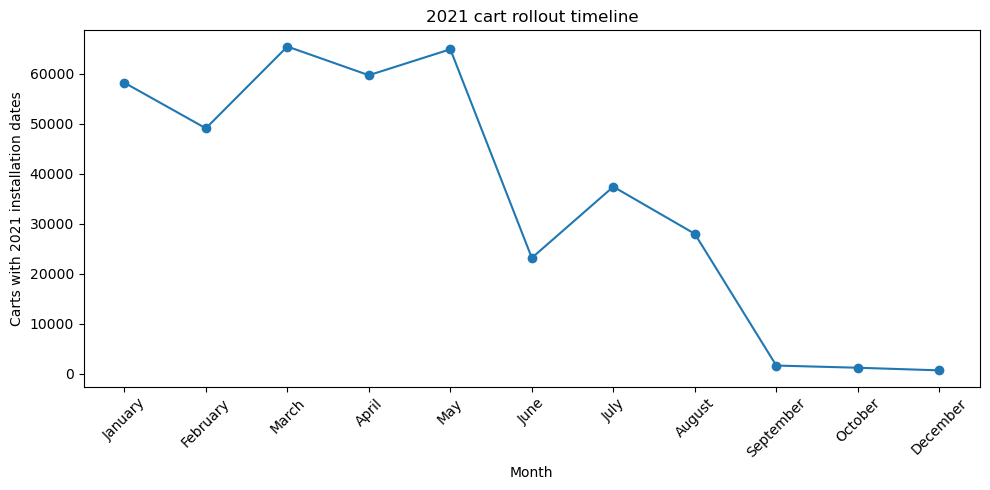

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_2021["month_name"], monthly_2021["carts_installed"], marker="o")
ax.set_title("2021 cart rollout timeline")
ax.set_xlabel("Month")
ax.set_ylabel("Carts with 2021 installation dates")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

A steep decline after the main rollout window suggests that the 2021 distribution was highly concentrated in time.

Missing months mean **no records were observed with those installation dates**. They should not automatically be interpreted as proof that no related operational activity occurred.

## 4. Product mix

Check whether the monthly rollout pattern changes by cart type. This helps avoid attributing a shift to geography when it may actually reflect a change in product mix.

In [9]:
monthly_products_2021 = api_query(
    CART_URL,
    {
        "$select": """
            date_extract_m(install_date) as month,
            product_description,
            sum(number_of_carts) as carts_installed
        """,
        "$where": """
            install_date >= '2021-01-01T00:00:00'
            AND install_date < '2022-01-01T00:00:00'
        """,
        "$group": """
            date_extract_m(install_date),
            product_description
        """,
        "$order": """
            date_extract_m(install_date),
            sum(number_of_carts) DESC
        """,
        "$limit": 50000
    }
)

monthly_products_2021["month"] = pd.to_numeric(monthly_products_2021["month"], errors="coerce")
monthly_products_2021["carts_installed"] = pd.to_numeric(
    monthly_products_2021["carts_installed"], errors="coerce"
)

product_pivot = (
    monthly_products_2021
    .pivot(index="month", columns="product_description", values="carts_installed")
    .fillna(0)
)

product_share = product_pivot.div(product_pivot.sum(axis=1), axis=0) * 100

product_pivot

product_description,120 Liter Garbage Cart,120 Liter Organic Cart,240 Liter Garbage Cart,360 Liter Garbage Cart
month,,,,
1,1.0,30250.0,27993.0,0.0
2,0.0,30365.0,18752.0,0.0
3,6125.0,25489.0,33884.0,0.0
4,4614.0,30041.0,24507.0,589.0
5,11157.0,20276.0,33514.0,0.0
6,0.0,0.0,23164.0,0.0
7,0.0,0.0,36842.0,577.0
8,503.0,5036.0,21861.0,585.0
9,914.0,0.0,225.0,464.0


In [10]:
product_share.round(1)

product_description,120 Liter Garbage Cart,120 Liter Organic Cart,240 Liter Garbage Cart,360 Liter Garbage Cart
month,,,,
1,0.0,51.9,48.1,0.0
2,0.0,61.8,38.2,0.0
3,9.4,38.9,51.7,0.0
4,7.7,50.3,41.0,1.0
5,17.2,31.2,51.6,0.0
6,0.0,0.0,100.0,0.0
7,0.0,0.0,98.5,1.5
8,1.8,18.0,78.1,2.1
9,57.0,0.0,14.0,28.9


## 5. Neighbourhood-level rollout

This section identifies the strongest neighbourhood activity by month and the peak rollout month for each neighbourhood.

In [11]:
monthly_neighbourhoods_2021 = api_query(
    CART_URL,
    {
        "$select": """
            date_extract_m(install_date) as month,
            neighbourhood_number,
            neighbourhood_name,
            sum(number_of_carts) as carts_installed
        """,
        "$where": """
            install_date >= '2021-01-01T00:00:00'
            AND install_date < '2022-01-01T00:00:00'
        """,
        "$group": """
            date_extract_m(install_date),
            neighbourhood_number,
            neighbourhood_name
        """,
        "$order": """
            date_extract_m(install_date),
            sum(number_of_carts) DESC
        """,
        "$limit": 50000
    }
)

monthly_neighbourhoods_2021["month"] = pd.to_numeric(
    monthly_neighbourhoods_2021["month"], errors="coerce"
)
monthly_neighbourhoods_2021["carts_installed"] = pd.to_numeric(
    monthly_neighbourhoods_2021["carts_installed"], errors="coerce"
)

top5_monthly = (
    monthly_neighbourhoods_2021
    .sort_values(["month", "carts_installed"], ascending=[True, False])
    .groupby("month", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

top5_monthly

,month,neighbourhood_number,neighbourhood_name,carts_installed
0,1,5570,WINDERMERE,2274
1,1,4487,SECORD,1665
2,1,4461,THE HAMPTONS,1521
3,1,6790,WILD ROSE,1465
4,1,5574,KESWICK,1458
5,2,6213,SUMMERSIDE,4457
6,2,6662,WALKER,3080
7,2,3180,DUNLUCE,2279
8,2,2340,HOLLICK-KENYON,2271
9,2,6216,THE ORCHARDS AT ELLERSLIE,1940


In [12]:
peak_month = (
    monthly_neighbourhoods_2021
    .sort_values(["neighbourhood_name", "carts_installed"], ascending=[True, False])
    .groupby("neighbourhood_name", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

peak_month["peak_month_name"] = peak_month["month"].map(MONTH_NAMES)

peak_month[
    ["neighbourhood_number", "neighbourhood_name", "peak_month_name", "carts_installed"]
].head(20)

,neighbourhood_number,neighbourhood_name,peak_month_name,carts_installed
0,2010,ABBOTTSFIELD,April,662
1,3460,ALBANY,March,384
2,1010,ALBERTA AVENUE,June,1048
3,4010,ALBERTA PARK INDUSTRIAL,February,4
4,6669,ALCES,May,10
5,4020,ALDERGROVE,January,654
6,5458,ALLARD,June,1648
7,5010,ALLENDALE,July,898
8,5505,AMBLESIDE,April,1165
9,4021,ANTHONY HENDAY HORSE HILL,February,3


## 6. Spatial analysis

The peak-month map tests whether rollout timing appears geographically structured.

In [13]:
geometry_df = api_query(
    CART_URL,
    {
        "$select": """
            neighbourhood_number,
            neighbourhood_name,
            geometry
        """,
        "$where": "geometry IS NOT NULL",
        "$group": """
            neighbourhood_number,
            neighbourhood_name,
            geometry
        """,
        "$limit": 1000
    }
)

geometry_df = geometry_df.dropna(subset=["geometry"]).copy()
geometry_df["neighbourhood_number"] = geometry_df["neighbourhood_number"].astype(str).str.strip()
geometry_df["geometry"] = geometry_df["geometry"].apply(wkt.loads)

edmonton_map = gpd.GeoDataFrame(
    geometry_df,
    geometry="geometry",
    crs="EPSG:4326"
)

edmonton_map.head()

,neighbourhood_number,neighbourhood_name,geometry
0,2010,ABBOTTSFIELD,"MULTIPOLYGON (((-113.38765 53.57614, -113.38887 53.57661, -113.39377 53.57792, -113.39404 53.57765, -113.39404 53.57732, -113.39404 53.5772, -113.39409 53.57717, -113.39409 53.57664, -113.3941 53.5751, -113.3937 53.5751, -113.39371 53.57433, -113.39371 53.57355, -113.39371 53.57277, -113.39372 53.57192, -113.39373 53.57038, -113.39138 53.57039, -113.38957 53.5704, -113.38854 53.57046, -113.38716 53.57071, -113.38526 53.57173, -113.38467 53.57229, -113.38438 53.57292, -113.38407 53.57361, -113.38364 53.57462, -113.38765 53.57614)))"
1,3460,ALBANY,"MULTIPOLYGON (((-113.56026 53.63161, -113.56228 53.62975, -113.56304 53.62905, -113.56321 53.62889, -113.56328 53.62883, -113.56337 53.62874, -113.55944 53.62873, -113.55353 53.62872, -113.54119 53.62872, -113.54119 53.63606, -113.54136 53.63606, -113.54144 53.63606, -113.54265 53.63606, -113.54279 53.63606, -113.54744 53.63606, -113.55006 53.63509, -113.55155 53.63454, -113.5525 53.63414, -113.55352 53.63371, -113.55353 53.63371, -113.55981 53.63175, -113.56026 53.63161)))"
2,1010,ALBERTA AVENUE,"MULTIPOLYGON (((-113.49227 53.57662, -113.49227 53.57533, -113.49227 53.57514, -113.49228 53.57355, -113.49228 53.57315, -113.49228 53.57196, -113.4923 53.57091, -113.49204 53.57038, -113.49183 53.56991, -113.49184 53.56886, -113.49181 53.56732, -113.49181 53.56578, -113.4918 53.56425, -113.49178 53.56271, -113.49177 53.56104, -113.49175 53.55948, -113.49186 53.55903, -113.49013 53.55915, -113.48952 53.5592, -113.48862 53.5595, -113.48702 53.56005, -113.4864 53.56025, -113.48565 53.56031, -113.48414 53.56044, -113.48266 53.56057, -113.48122 53.56082, -113.47965 53.5611, -113.47925 53.56103, -113.47816 53.56104, -113.47817 53.56276, -113.47818 53.5643, -113.4782 53.56583, -113.47822 53.56737, -113.47823 53.5689, -113.47824 53.5704, -113.47797 53.5704, -113.47798 53.57196, -113.47797 53.57355, -113.47798 53.57514, -113.47798 53.57673, -113.47963 53.57663, -113.48124 53.57663, -113.4827 53.57663, -113.48425 53.57663, -113.48579 53.57663, -113.48735 53.57663, -113.48889 53.57663, -113.49043 53.57663, -113.49227 53.57662)))"
3,4010,ALBERTA PARK INDUSTRIAL,"MULTIPOLYGON (((-113.59042 53.56654, -113.59043 53.57043, -113.59717 53.57043, -113.60284 53.57044, -113.60277 53.56959, -113.60258 53.56863, -113.60258 53.56811, -113.60254 53.56655, -113.60259 53.56466, -113.60274 53.56408, -113.6028 53.5636, -113.60279 53.56304, -113.59716 53.56306, -113.59042 53.56307, -113.59041 53.5645, -113.59041 53.5656, -113.59042 53.56654)))"
4,6669,ALCES,"MULTIPOLYGON (((-113.3765 53.42488, -113.36905 53.42489, -113.36759 53.42491, -113.34973 53.4249, -113.34465 53.4249, -113.34465 53.42498, -113.34464 53.42926, -113.34464 53.43221, -113.34464 53.43225, -113.34464 53.43238, -113.34464 53.4324, -113.34463 53.43273, -113.34463 53.43273, -113.34463 53.43465, -113.34463 53.43546, -113.34463 53.43556, -113.34463 53.43581, -113.34462 53.43765, -113.34462 53.43943, -113.34462 53.43943, -113.34462 53.44004, -113.34462 53.44005, -113.34462 53.44103, -113.34462 53.44158, -113.34476 53.44158, -113.34485 53.44158, -113.34778 53.44152, -113.34778 53.44152, -113.34984 53.44117, -113.35539 53.44022, -113.35596 53.44011, -113.35674 53.43994, -113.35746 53.43979, -113.35766 53.43975, -113.35926 53.43942, -113.3604 53.43889, -113.36134 53.43845, -113.36208 53.43811, -113.36227 53.43777, -113.3625 53.43734, -113.36304 53.43636, -113.3631 53.43635, -113.36404 53.43621, -113.36448 53.43614, -113.36688 53.43579, -113.36735 53.43572, -113.36742 53.43478, -113.36751 53.4335, -113.36753 53.43329, -113.36754 53.43307, -113.36825 53.43228, -113.36859 53.43215, -113.36886 53.43215, -113.36893 53.43215, -113.36901 53.43215, -113.36916 53.43215, -113.37859 53.43215, -113.3813 53.43215, -113.38153 53.43215, -113.38609 53.43215, -113.39202 53.43215, -113.39342 53.43215, -113.39342 53.43215, -113.39357 53.43215, -113.39356 53.42488, -113.3933 53.42487, -113.3765 53.42488)))"


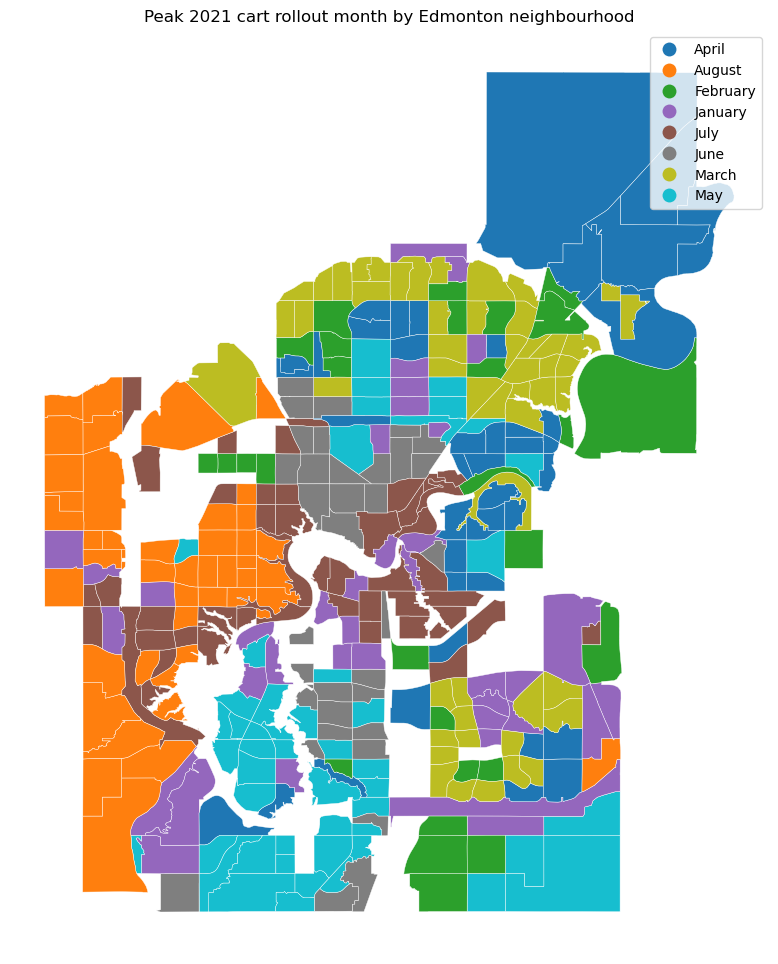

In [14]:
peak_for_map = peak_month.copy()
peak_for_map["neighbourhood_number"] = peak_for_map["neighbourhood_number"].astype(str).str.strip()

peak_map = edmonton_map.merge(
    peak_for_map[["neighbourhood_number", "peak_month_name", "carts_installed"]],
    on="neighbourhood_number",
    how="left",
    validate="1:1"
)

fig, ax = plt.subplots(figsize=(12, 12))
peak_map.plot(
    column="peak_month_name",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)
ax.set_title("Peak 2021 cart rollout month by Edmonton neighbourhood")
ax.axis("off")
plt.show()

## 7. Build the core neighbourhood table

From this point forward, the analysis uses one row per neighbourhood.

In [15]:
total_2021_by_neighbourhood = api_query(
    CART_URL,
    {
        "$select": """
            neighbourhood_number,
            neighbourhood_name,
            sum(number_of_carts) as carts_installed
        """,
        "$where": """
            install_date >= '2021-01-01T00:00:00'
            AND install_date < '2022-01-01T00:00:00'
        """,
        "$group": """
            neighbourhood_number,
            neighbourhood_name
        """,
        "$order": "sum(number_of_carts) DESC",
        "$limit": 5000
    }
)

total_2021_by_neighbourhood["neighbourhood_number"] = (
    total_2021_by_neighbourhood["neighbourhood_number"].astype(str).str.strip()
)
total_2021_by_neighbourhood["carts_installed"] = pd.to_numeric(
    total_2021_by_neighbourhood["carts_installed"], errors="coerce"
)

total_2021_by_neighbourhood.head(15)

,neighbourhood_number,neighbourhood_name,carts_installed
0,6213,SUMMERSIDE,8169
1,5462,CHAPPELLE,6478
2,6662,WALKER,6472
3,5570,WINDERMERE,5746
4,5454,RUTHERFORD,5574
5,2522,MCCONACHIE,5200
6,6444,LAUREL,4889
7,4461,THE HAMPTONS,4598
8,4487,SECORD,4337
9,5511,TWIN BROOKS,4317


## 8. Normalize by actual 2021 population

Using actual 2021 neighbourhood population is preferable to extrapolating the 2019 municipal census.

In [16]:
population_2021 = api_query(POP_2021_URL, {"$limit": 5000})

population_2021["neighbourhood_number"] = (
    population_2021["neighbourhood_number"].astype(str).str.strip()
)
population_2021["total_population"] = pd.to_numeric(
    population_2021["total_population"], errors="coerce"
)

analysis_2021 = total_2021_by_neighbourhood.merge(
    population_2021[
        ["neighbourhood_number", "neighbourhood", "total_population", "ward"]
    ],
    on="neighbourhood_number",
    how="left",
    validate="1:1"
)

analysis_2021["carts_per_1000_residents"] = (
    analysis_2021["carts_installed"]
    / analysis_2021["total_population"]
    * 1000
)

print("Population join matched:",
      analysis_2021["total_population"].notna().sum(),
      "of",
      len(analysis_2021))

analysis_2021[
    ["neighbourhood_name", "carts_installed", "total_population", "carts_per_1000_residents"]
].sort_values("carts_per_1000_residents", ascending=False).head(20)

Population join matched: 273 of 332


,neighbourhood_name,carts_installed,total_population,carts_per_1000_residents
113,GLENRIDDING RAVINE,1280,860.0,1488.372093
148,THE UPLANDS,1127,830.0,1357.831325
76,IDYLWYLDE,1566,1720.0,910.465116
134,EVERGREEN,1190,1420.0,838.028169
92,PAISLEY,1444,1740.0,829.885057
236,HAYS RIDGE AREA,482,595.0,810.084034
46,CAPILANO,2110,2650.0,796.226415
260,KINGLET GARDENS,237,305.0,777.049180
70,MCLEOD,1712,2260.0,757.522124
34,BEVERLY HEIGHTS,2441,3250.0,751.076923


### Why population is not the final denominator

Residential carts are linked more directly to households or dwellings than to individual residents. A neighbourhood with smaller households can naturally have more carts per resident than a neighbourhood with larger households.

For operational benchmarking, occupied dwellings are more relevant.

## 9. Normalize by occupied private dwellings

The 2021 Census short-form dataset is in long format. `characteristics_code = 34` identifies the total occupied private dwellings measure used here.

In [17]:
dwellings_2021 = api_query(
    CENSUS_2021_SHORT_URL,
    {
        "$select": """
            neighbourhood_number,
            neighbourhood_name,
            total_gender
        """,
        "$where": """
            characteristics_code = '34'
            AND neighbourhood_number IS NOT NULL
        """,
        "$limit": 5000
    }
)

dwellings_2021 = dwellings_2021.rename(
    columns={"total_gender": "occupied_dwellings_2021"}
)

dwellings_2021["neighbourhood_number"] = (
    dwellings_2021["neighbourhood_number"].astype(str).str.strip()
)
dwellings_2021["occupied_dwellings_2021"] = pd.to_numeric(
    dwellings_2021["occupied_dwellings_2021"], errors="coerce"
)

dwellings_2021.head()

,neighbourhood_number,neighbourhood_name,occupied_dwellings_2021
0,1010,ALBERTA AVENUE,2895
1,1020,BOYLE STREET,3545
2,1030,CENTRAL MCDOUGALL,2565
3,1070,CROMDALE,1045
4,1080,DELTON,835


In [18]:
analysis_2021 = analysis_2021.merge(
    dwellings_2021[["neighbourhood_number", "occupied_dwellings_2021"]],
    on="neighbourhood_number",
    how="left",
    validate="1:1"
)

analysis_2021["carts_per_1000_dwellings"] = (
    analysis_2021["carts_installed"]
    / analysis_2021["occupied_dwellings_2021"]
    * 1000
)

print("Dwelling join matched:",
      analysis_2021["occupied_dwellings_2021"].notna().sum(),
      "of",
      len(analysis_2021))

analysis_2021[
    [
        "neighbourhood_name",
        "carts_installed",
        "occupied_dwellings_2021",
        "carts_per_1000_dwellings"
    ]
].sort_values("carts_per_1000_dwellings", ascending=False).head(20)

Dwelling join matched: 274 of 332


,neighbourhood_name,carts_installed,occupied_dwellings_2021,carts_per_1000_dwellings
113,GLENRIDDING RAVINE,1280,305.0,4196.721311
148,THE UPLANDS,1127,305.0,3695.081967
236,HAYS RIDGE AREA,482,200.0,2410.000000
86,DESROCHERS AREA,1511,665.0,2272.180451
92,PAISLEY,1444,655.0,2204.580153
260,KINGLET GARDENS,237,115.0,2060.869565
11,THE ORCHARDS AT ELLERSLIE,4203,2080.0,2020.673077
32,MAYLIEWAN,2543,1275.0,1994.509804
70,MCLEOD,1712,865.0,1979.190751
46,CAPILANO,2110,1080.0,1953.703704


### Interpretation of the dwelling-based KPI

`2021-install-date carts per 1,000 occupied dwellings` is the most operationally useful measure in this notebook, but it is **not a literal coverage rate**.

Reasons:

- Census 2021 is a point-in-time snapshot.
- Cart installation dates span the full year.
- Fast-growing neighbourhoods can add homes after Census Day.
- Multiple cart types can exist for the same dwelling.

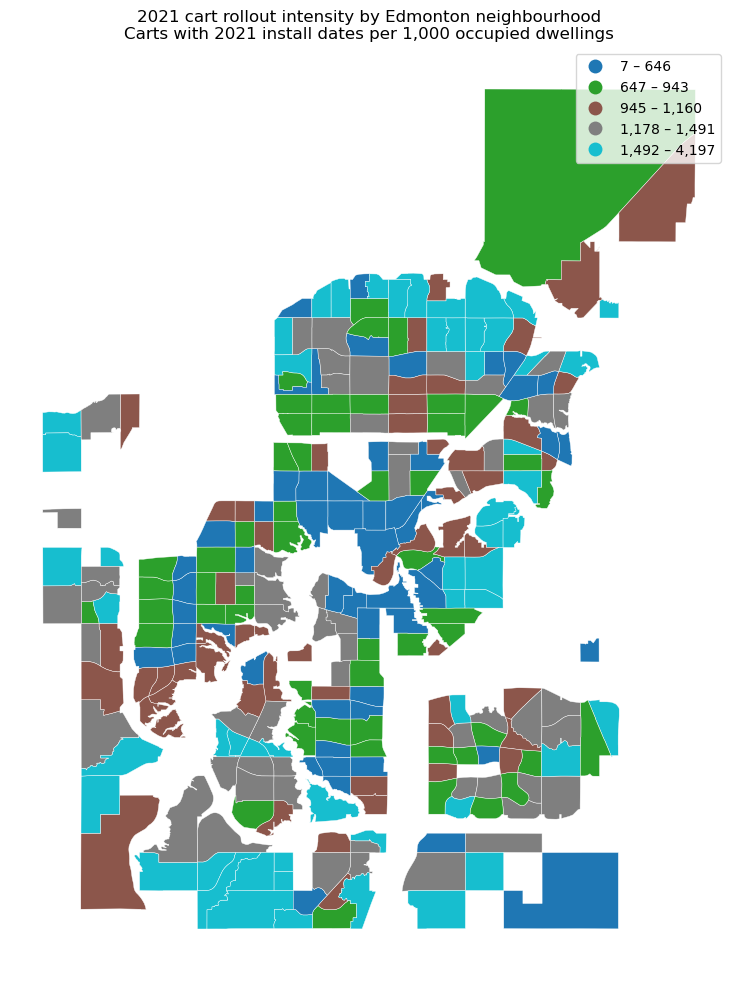

In [19]:
map_dwellings = edmonton_map.merge(
    analysis_2021[["neighbourhood_number", "carts_per_1000_dwellings"]],
    on="neighbourhood_number",
    how="left",
    validate="1:1"
)

map_dwellings["quantile_bin"] = pd.qcut(
    map_dwellings["carts_per_1000_dwellings"],
    q=5,
    labels=False,
    duplicates="drop"
)

quantile_summary = (
    map_dwellings
    .dropna(subset=["quantile_bin"])
    .groupby("quantile_bin")["carts_per_1000_dwellings"]
    .agg(["min", "max", "count"])
)

labels = {
    idx: f"{row['min']:,.0f} – {row['max']:,.0f}"
    for idx, row in quantile_summary.iterrows()
}

map_dwellings["intensity_group"] = map_dwellings["quantile_bin"].map(labels)
ordered_labels = [labels[i] for i in sorted(labels)]

map_dwellings["intensity_group"] = pd.Categorical(
    map_dwellings["intensity_group"],
    categories=ordered_labels,
    ordered=True
)

fig, ax = plt.subplots(figsize=(12, 12))
map_dwellings.plot(
    column="intensity_group",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)
ax.set_title(
    "2021 cart rollout intensity by Edmonton neighbourhood\n"
    "Carts with 2021 install dates per 1,000 occupied dwellings"
)
ax.axis("off")
plt.show()

## 10. Neighbourhood growth, 2019–2021

This section tests whether rapidly growing neighbourhoods tend to have higher rollout intensity.

**Caution:** 2019 values come from the Edmonton Municipal Census and 2021 values come from the Federal Census. The percentage change should therefore be treated as an **exploratory growth proxy**, not as a perfectly harmonized official time series.

In [20]:
population_raw_2019 = api_query(
    POP_2019_URL,
    {
        "$select": """
            neighbourhood_number,
            neighbourhood_name,
            age_range,
            population
        """,
        "$limit": 50000
    }
)

population_raw_2019["population"] = pd.to_numeric(
    population_raw_2019["population"], errors="coerce"
)
population_raw_2019["neighbourhood_number"] = (
    population_raw_2019["neighbourhood_number"].astype(str).str.strip()
)

population_2019 = (
    population_raw_2019
    .groupby(["neighbourhood_number", "neighbourhood_name"], as_index=False)["population"]
    .sum()
    .rename(columns={"population": "population_2019"})
)

population_2019.head()

,neighbourhood_number,neighbourhood_name,population_2019
0,1010,Alberta Avenue,6581
1,1020,Boyle Street,6761
2,1030,Central McDougall,5115
3,1070,Cromdale,2006
4,1080,Delton,1941


In [21]:
growth_df = population_2019.merge(
    population_2021[["neighbourhood_number", "total_population"]],
    on="neighbourhood_number",
    how="inner",
    validate="1:1"
).rename(columns={"total_population": "population_2021"})

growth_df["population_change"] = (
    growth_df["population_2021"] - growth_df["population_2019"]
)

growth_df["population_growth_pct"] = (
    growth_df["population_change"]
    / growth_df["population_2019"]
    * 100
)

growth_df["population_growth_pct"] = (
    growth_df["population_growth_pct"]
    .replace([np.inf, -np.inf], np.nan)
)

growth_analysis = analysis_2021.merge(
    growth_df[
        [
            "neighbourhood_number",
            "population_2019",
            "population_2021",
            "population_change",
            "population_growth_pct"
        ]
    ],
    on="neighbourhood_number",
    how="left",
    validate="1:1"
)

growth_analysis[
    [
        "neighbourhood_name",
        "population_2019",
        "population_2021",
        "population_growth_pct",
        "occupied_dwellings_2021",
        "carts_installed",
        "carts_per_1000_dwellings"
    ]
].sort_values("carts_per_1000_dwellings", ascending=False).head(20)

,neighbourhood_name,population_2019,population_2021,population_growth_pct,occupied_dwellings_2021,carts_installed,carts_per_1000_dwellings
113,GLENRIDDING RAVINE,0.0,860.0,NaN,305.0,1280,4196.721311
148,THE UPLANDS,269.0,830.0,208.550186,305.0,1127,3695.081967
236,HAYS RIDGE AREA,438.0,595.0,35.844749,200.0,482,2410.000000
86,DESROCHERS AREA,1133.0,2100.0,85.348632,665.0,1511,2272.180451
92,PAISLEY,1334.0,1740.0,30.434783,655.0,1444,2204.580153
260,KINGLET GARDENS,138.0,305.0,121.014493,115.0,237,2060.869565
11,THE ORCHARDS AT ELLERSLIE,4126.0,6270.0,51.963160,2080.0,4203,2020.673077
32,MAYLIEWAN,4128.0,4110.0,-0.436047,1275.0,2543,1994.509804
70,MCLEOD,2222.0,2260.0,1.710171,865.0,1712,1979.190751
46,CAPILANO,2703.0,2650.0,-1.960784,1080.0,2110,1953.703704


To reduce unstable percentage growth caused by very small 2019 population bases, the correlation analysis below keeps neighbourhoods with at least 500 residents in 2019.

In [22]:
growth_filtered = growth_analysis[
    (growth_analysis["population_2019"] >= 500)
    & growth_analysis["population_growth_pct"].notna()
    & growth_analysis["carts_per_1000_dwellings"].notna()
].copy()

pearson_corr = growth_filtered["population_growth_pct"].corr(
    growth_filtered["carts_per_1000_dwellings"],
    method="pearson"
)

spearman_corr = growth_filtered["population_growth_pct"].corr(
    growth_filtered["carts_per_1000_dwellings"],
    method="spearman"
)

absolute_corr = growth_filtered["population_change"].corr(
    growth_filtered["carts_installed"]
)

print("Pearson: growth % vs rollout intensity =", round(pearson_corr, 3))
print("Spearman: growth % vs rollout intensity =", round(spearman_corr, 3))
print("Absolute population increase vs carts =", round(absolute_corr, 3))

Pearson: growth % vs rollout intensity = 0.299
Spearman: growth % vs rollout intensity = 0.252
Absolute population increase vs carts = 0.524


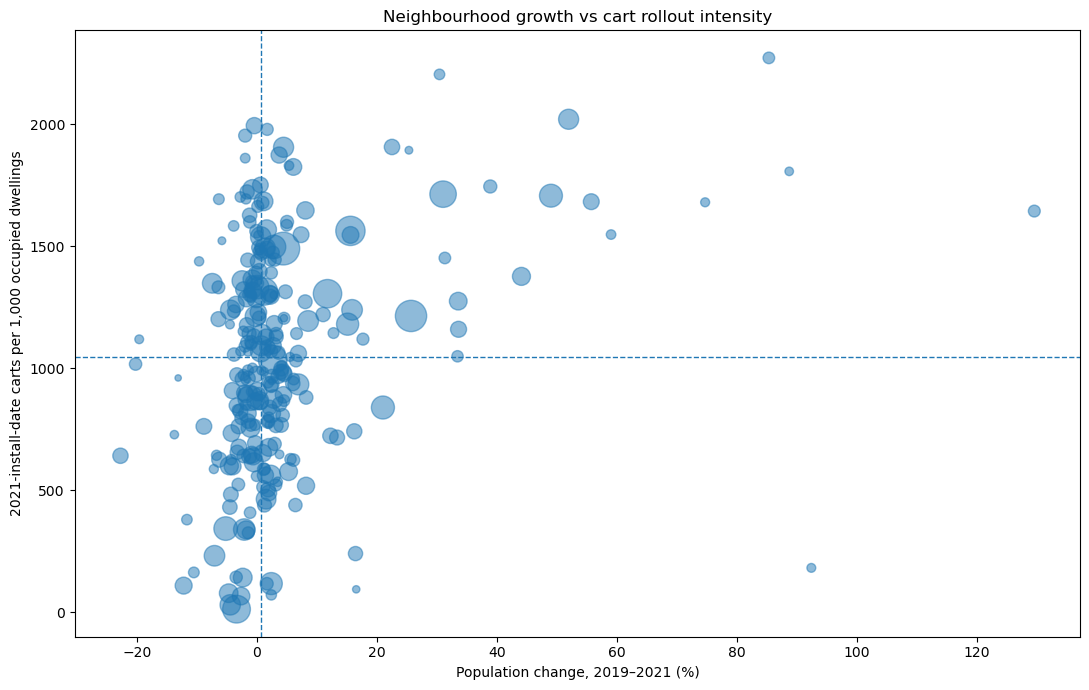

In [23]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    growth_filtered["population_growth_pct"],
    growth_filtered["carts_per_1000_dwellings"],
    s=growth_filtered["population_2021"] / 30,
    alpha=0.5
)

ax.axhline(
    growth_filtered["carts_per_1000_dwellings"].median(),
    linestyle="--",
    linewidth=1
)

ax.axvline(
    growth_filtered["population_growth_pct"].median(),
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Population change, 2019–2021 (%)")
ax.set_ylabel("2021-install-date carts per 1,000 occupied dwellings")
ax.set_title("Neighbourhood growth vs cart rollout intensity")

plt.tight_layout()
plt.show()

## 11. Four-segment neighbourhood classification

Median splits create four descriptive groups. This is a segmentation tool, **not a performance ranking**.

In [24]:
growth_median = growth_filtered["population_growth_pct"].median()
rollout_median = growth_filtered["carts_per_1000_dwellings"].median()

def classify_neighbourhood(row):
    high_growth = row["population_growth_pct"] >= growth_median
    high_rollout = row["carts_per_1000_dwellings"] >= rollout_median

    if high_growth and high_rollout:
        return "High growth / High rollout"
    if high_growth and not high_rollout:
        return "High growth / Lower rollout"
    if not high_growth and high_rollout:
        return "Lower growth / High rollout"
    return "Lower growth / Lower rollout"

growth_filtered["segment"] = growth_filtered.apply(
    classify_neighbourhood,
    axis=1
)

growth_filtered["segment"].value_counts()

segment
High growth / High rollout      69
Lower growth / Lower rollout    68
High growth / Lower rollout     62
Lower growth / High rollout     62
Name: count, dtype: int64

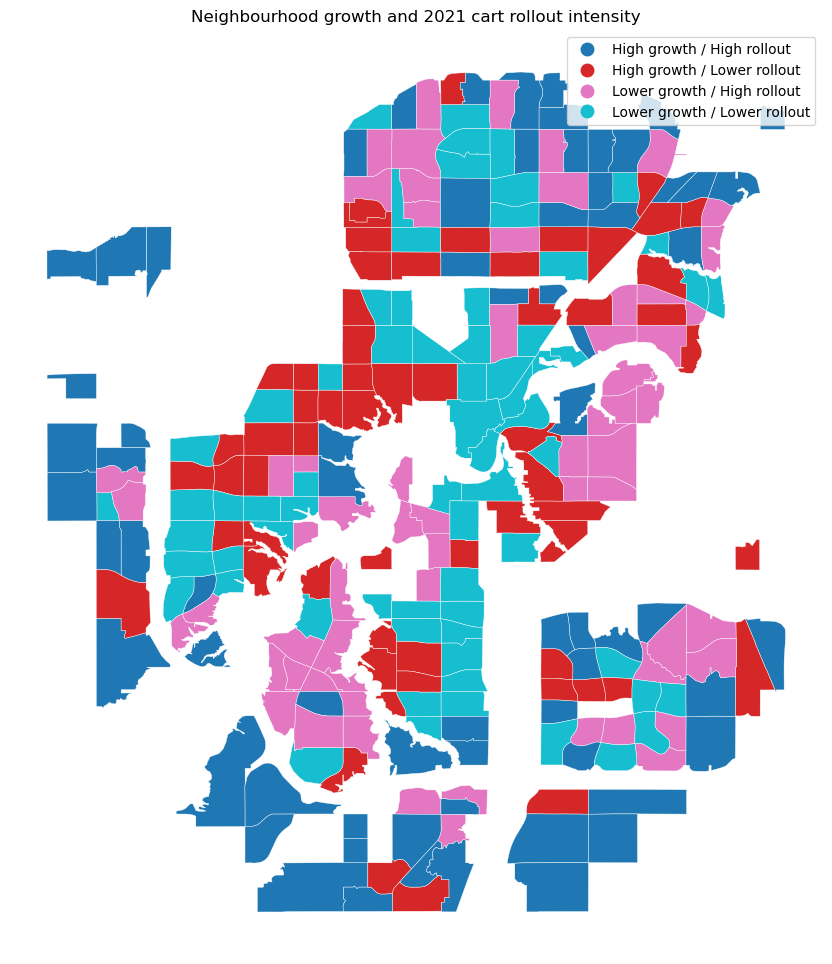

In [25]:
segment_map = edmonton_map.merge(
    growth_filtered[["neighbourhood_number", "segment"]],
    on="neighbourhood_number",
    how="left",
    validate="1:1"
)

fig, ax = plt.subplots(figsize=(12, 12))
segment_map.plot(
    column="segment",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)
ax.set_title("Neighbourhood growth and 2021 cart rollout intensity")
ax.axis("off")
plt.show()

## 12. Outlier analysis

The IQR method flags unusually high cart-to-dwelling intensity. These neighbourhoods should be investigated rather than automatically treated as errors.

In [26]:
outlier_base = growth_analysis[
    growth_analysis["carts_per_1000_dwellings"].notna()
].copy()

q1 = outlier_base["carts_per_1000_dwellings"].quantile(0.25)
q3 = outlier_base["carts_per_1000_dwellings"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

all_outliers = (
    outlier_base[
        outlier_base["carts_per_1000_dwellings"] > upper_bound
    ][
        [
            "neighbourhood_name",
            "population_2019",
            "population_2021",
            "population_growth_pct",
            "occupied_dwellings_2021",
            "carts_installed",
            "carts_per_1000_dwellings"
        ]
    ]
    .sort_values("carts_per_1000_dwellings", ascending=False)
)

print("Upper IQR outlier threshold:", round(upper_bound, 1))
all_outliers

Upper IQR outlier threshold: 2323.6


,neighbourhood_name,population_2019,population_2021,population_growth_pct,occupied_dwellings_2021,carts_installed,carts_per_1000_dwellings
113,GLENRIDDING RAVINE,0.0,860.0,NaN,305.0,1280,4196.721311
148,THE UPLANDS,269.0,830.0,208.550186,305.0,1127,3695.081967
236,HAYS RIDGE AREA,438.0,595.0,35.844749,200.0,482,2410.000000


## 13. Automated headline metrics

This cell produces a few concise metrics that can be copied into the executive summary after the notebook has been run successfully.

In [27]:
year_2021_share = (
    yearly.loc[yearly["year"] == 2021, "carts_installed"].iloc[0]
    / yearly["carts_installed"].sum()
)

highest_intensity = (
    analysis_2021
    .dropna(subset=["carts_per_1000_dwellings"])
    .sort_values("carts_per_1000_dwellings", ascending=False)
    .iloc[0]
)

print(f"2021 share of carts in the installation-date distribution: {year_2021_share:.1%}")
print(f"January-August share of 2021 install-date carts: {jan_aug / total_2021:.1%}")
print(
    "Highest dwelling-normalized intensity:",
    highest_intensity["neighbourhood_name"],
    f"({highest_intensity['carts_per_1000_dwellings']:,.0f} per 1,000 occupied dwellings)"
)
print(f"Pearson growth-intensity correlation: {pearson_corr:.3f}")
print(f"Spearman growth-intensity correlation: {spearman_corr:.3f}")

2021 share of carts in the installation-date distribution: 71.4%
January-August share of 2021 install-date carts: 99.1%
Highest dwelling-normalized intensity: GLENRIDDING RAVINE (4,197 per 1,000 occupied dwellings)
Pearson growth-intensity correlation: 0.299
Spearman growth-intensity correlation: 0.252


## 14. Key findings

After running the notebook, the final narrative should focus on evidence from the outputs rather than on assumptions.

A strong final interpretation is likely to include these themes:

**2021 was the dominant install-date year.** The active-cart snapshot is heavily concentrated in 2021, making that year the natural focus of the rollout analysis.

**Rollout timing was concentrated and spatially uneven.** Monthly neighbourhood leaders and peak-month mapping indicate that different parts of Edmonton reached peak activity at different times.

**Normalization materially changes the story.** Absolute cart counts largely reflect neighbourhood size. Population helps, but occupied dwellings are the more relevant operational denominator.

**Fast growth explains some, but not all, high rollout intensity.** Newer neighbourhoods can show very high cart-to-dwelling ratios because the Census denominator is a point-in-time snapshot while installations continue through the year. At the same time, some established neighbourhoods also show high intensity.

**Extreme ratios require investigation, not automatic rejection.** They may reflect development timing, product mix, boundary effects, or data-quality issues.

## 15. Operational implications

The analysis supports several practical directions for deeper work:

**Planning denominators:** use occupied dwellings rather than total population when benchmarking residential cart infrastructure.

**Growth monitoring:** supplement Census counts with more frequently updated housing or development data in fast-growing neighbourhoods.

**Operational separation:** distinguish one-time city-wide rollout activity from ongoing cart demand generated by new residential development.

**Data quality:** review extreme neighbourhood ratios before using them for forecasting or resource allocation.

**Next data links:** development permits, dwelling completions, 311 service requests, missed collections, route data, and waste tonnage would allow the analysis to move from infrastructure rollout toward service performance and operational efficiency.

## 16. Limitations

- Cart Counts is an active-cart snapshot rather than a complete installation/removal history.
- Census reference dates and installation dates are not perfectly aligned.
- Multiple product types can exist for one dwelling.
- 2019 and 2021 population figures come from different census programs.
- Neighbourhood definitions can change over time.
- Correlation does not establish causation.
- Cart counts do not measure waste generation, collection cost, route efficiency, missed collections, or service quality.

### Recommended next phase

Link the cart analysis to **development permits or dwelling growth**, then test whether new residential construction predicts incremental cart demand after the 2021 city-wide rollout.